<a href="https://colab.research.google.com/github/sp6jaz/python2-materialy/blob/master/dzienne/tydzien-12/wyklad/hypothesis_demo.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

**Dwie ścieżki pracy:**
- **Lokalna (zalecana)**: VS Code + venv + Jupyter — pełna kontrola, kod zostaje na Twoim komputerze.
- **Colab (kliknij i działa)**: środowisko Google gotowe w 5 sekund, działa nawet z telefonu. Kliknij ikonę powyżej.

# Statystyka — rozkłady i testy hipotez

**Programowanie w Pythonie II** | Wykład 12
**Politechnika Opolska** | Analityka danych w biznesie

---

## Co dzisiaj?

W11 nauczyliśmy się **opisywać** dane — średnia, mediana, std, korelacja, skośność, outliery. Wiemy *co się dzieje w naszych danych*. Ale to wciąż za mało, żeby podjąć decyzję biznesową.

Pytanie biznesowe brzmi zwykle inaczej: **Czy wariant B kampanii działa lepiej niż A?** **Czy szkolenie skróciło czas obsługi?** **Czy nowa wersja strony zwiększa konwersję, czy to po prostu szum w danych?**

Tu wchodzi **statystyka inferencyjna** (wnioskująca — z próby do populacji) — czyli testowanie hipotez. Nauczymy się **kalibrować ryzyko błędnej decyzji**: kiedy „efekt” jest na tyle wyraźny, że warto na nim opierać działania biznesowe, a kiedy to tylko losowa fluktuacja (przypadkowe wahanie danych, które wygląda jak wzór).

```mermaid
graph TD
    A["Pytanie biznesowe<br/>Czy wariant B działa?"] --> B["Hipotezy<br/>H0 vs H1"]
    B --> C["Test statystyczny"]
    C --> D["p-value<br/>jest efekt?"]
    C --> E["Effect size<br/>jak duży?"]
    C --> F["Przedział ufności<br/>jak precyzyjnie?"]
    D --> G["Decyzja biznesowa"]
    E --> G
    F --> G
```

### Po tym wykładzie potrafisz:

1. **Wyjaśnić** logikę testu hipotez: H0/H1 (hipoteza zerowa/alternatywna), poziom istotności α (alpha), p-value, błędy I i II rodzaju (false positive / false negative), moc testu (power)
2. **Stosować** t-test (test Studenta) za pomocą `scipy.stats.ttest_*` — 1-próbkowy, 2-próbkowy niezależny (independent), sparowany (paired)
3. **Stosować** chi-kwadrat (`chi2_contingency`) do testowania niezależności zmiennych kategorialnych i zgodności z rozkładem
4. **Obliczać** 95% przedział ufności (Confidence Interval, CI) dla średniej i proporcji oraz **poprawnie** go interpretować
5. **Analizować** A/B test: formułować hipotezy, dobierać test, raportować **trójką**: p-value + effect size (Cohen's d) + CI
6. **Oceniać krytycznie** twierdzenia statystyczne („p=0.06 → efekt nie istnieje”; „p<0.001 → wielki efekt”; „95% CI = 95% klientów”) — korygować błędne interpretacje
7. **Wybierać** test parametryczny vs nieparametryczny (Mann-Whitney, Wilcoxon) na podstawie założeń (normalność, równość wariancji)

**Dokumentacja:** [scipy.stats](https://docs.scipy.org/doc/scipy/reference/stats.html) | [statsmodels stats](https://www.statsmodels.org/stable/stats.html) | [ASA Statement on p-values](https://www.amstat.org/asa/files/pdfs/p-valuestatement.pdf)

## 0. Dlaczego sama liczba `p=0.04` to za mało

Zanim wejdziemy w teorię — pokazowy paradoks. Mamy **dwie firmy** raportujące wyniki A/B testu kampanii. Obie podają: **p ≈ 0.04, czyli „statystycznie istotne”**. Obie chcą zwiększyć budżet.

Komu dasz zielone światło?

In [1]:
import numpy as np
import pandas as pd
from scipy import stats

np.random.seed(42)

# Firma A: ogromna próba (n=20000), mały efekt (5.00% → 5.50%)
n_A = 20_000
konwersja_A_kontrol = np.random.binomial(1, 0.0500, n_A)  # baseline 5%
konwersja_A_wariant = np.random.binomial(1, 0.0550, n_A)  # +0.5 pp (efekt mały)
# różnica: 5.00% vs 5.50% — 0.5 pp (+10% względnie, mały biznesowo)

# Firma B: mała próba (n=200), silny efekt względny (5% → 10%)
np.random.seed(42)  # reset seed dla powtarzalności B niezależnie od A
n_B = 200
konwersja_B_kontrol = np.random.binomial(1, 0.05, n_B)
konwersja_B_wariant = np.random.binomial(1, 0.10, n_B)
# różnica: 5% vs 10% — 5 pp (+100% wzrostu względnego, ogromny biznesowo)

def chi2_p(k, w):
    table = [[k.sum(), len(k) - k.sum()],
             [w.sum(), len(w) - w.sum()]]
    chi2, p, _, _ = stats.chi2_contingency(table)
    return p, k.mean(), w.mean()

p_A, kA, wA = chi2_p(konwersja_A_kontrol, konwersja_A_wariant)
p_B, kB, wB = chi2_p(konwersja_B_kontrol, konwersja_B_wariant)

print(f'Firma A (n={n_A:>6}):  kontrol = {kA:.4%}, wariant = {wA:.4%}, p = {p_A:.4f}')
print(f'Firma B (n={n_B:>6}):  kontrol = {kB:.4%}, wariant = {wB:.4%}, p = {p_B:.4f}')

Firma A (n= 20000):  kontrol = 4.9950%, wariant = 5.4700%, p = 0.0348
Firma B (n=   200):  kontrol = 4.0000%, wariant = 9.5000%, p = 0.0463


**Obie kampanie mają `p ≈ 0.04`**, ale to dwie zupełnie różne historie:

| Firma | Różnica konwersji | Względny wzrost | Decyzja |
|-------|-------------------|-----------------|---------|
| **A** | 5.00% → 5.47% (+0.47 pp) | +9.5% | Statystycznie istotne, **biznesowo skromne** — koszt wdrożenia rozważ |
| **B** | 4.00% → 9.50% (+5.5 pp) | +138% | Statystycznie istotne, **biznesowo ogromne** — wdrażaj natychmiast |

**Wniosek**: Sama liczba p-value nie wystarcza do decyzji biznesowej. Potrzebujemy **trójki**:

1. **p-value** — czy efekt jest odróżnialny od szumu (tak / nie)
2. **effect size** — jak duży efekt (np. różnica średnich, Cohen's d, różnica proporcji)
3. **95% CI** — jak precyzyjnie zmierzony (niepewność estymatora)

To jest **klucz dzisiejszego wykładu** — i to zobaczymy w finalnym raporcie A/B w Sekcji 8.

## 1. Setup — wersje pakietów i dataset

Pracujemy z pakietami: `numpy`, `pandas`, `scipy.stats` (główne narzędzie), `statsmodels` (power analysis, CI dla proporcji), `matplotlib`, `seaborn`. Wszystkie są w pliku `requirements.txt` z W01 — `uv pip install -r requirements.txt` jeśli czegoś brakuje.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats import proportion as smprop
from statsmodels.stats.power import TTestIndPower

%matplotlib inline
sns.set_theme(style='whitegrid', palette='colorblind')

import numpy, pandas, scipy, statsmodels, matplotlib, seaborn
print(f'numpy        : {numpy.__version__}')
print(f'pandas       : {pandas.__version__}')
print(f'scipy        : {scipy.__version__}')
print(f'statsmodels  : {statsmodels.__version__}')
print(f'matplotlib   : {matplotlib.__version__}')
print(f'seaborn      : {seaborn.__version__}')

numpy        : 2.4.2
pandas       : 3.0.1
scipy        : 1.17.1
statsmodels  : 0.14.6
matplotlib   : 3.10.8
seaborn      : 0.13.2


### 1.1. Dataset główny — kampania marketingowa A/B

Symulujemy dane realistycznego A/B testu kampanii e-commerce. Dwie grupy klientów: **kontrol** (stara wersja **landing page** — strony docelowej kampanii) i **wariant** (nowy **CTA** — *call-to-action*, przycisk wezwania do akcji, np. „Kup teraz”).

**Skąd `np.random.gamma`?** Symulujemy realistyczne dane biznesowe, które w naturalny sposób są **prawoskośne** (długi ogon po prawej): wartości koszyka, czasy reakcji, wartości transakcji — wszystkie naturalnie pasują do rozkładu gamma (a nie do symetrycznego normalnego). Parametry `shape` i `scale` kontrolują kształt i rozproszenie — szczegóły to nie jest temat W12, ważne że uzyskujemy realistycznie skośne dane.

Dla każdego klienta mierzymy:
- `kupil` — czy kupił (0/1) → analiza konwersji (chi², test proporcji)
- `wartosc_koszyka` — wartość zakupu w PLN (0 jeśli nie kupił) → analiza średniej (t-test)
- `czas_na_stronie` — sekundy na landing page → analiza zaangażowania
- `segment` — typ klienta (nowy / powracający) → analiza niezależności (chi²)

In [3]:
np.random.seed(42)

n_per_group = 2500  # 2500 klientów w każdej grupie (n dobrane tak, by chi² wykrył efekt przy α=0.05)

# KONTROL: konwersja 5%, średnia koszyka 180 PLN, średni czas 65 s
kontrol_kupil = np.random.binomial(1, 0.050, n_per_group)
kontrol_koszyk = np.where(kontrol_kupil == 1,
                          np.random.gamma(shape=4, scale=45, size=n_per_group),
                          0)
kontrol_czas = np.random.gamma(shape=3, scale=22, size=n_per_group).clip(5, 600)
kontrol_segment = np.random.choice(['nowy', 'powracajacy'], n_per_group, p=[0.65, 0.35])

# WARIANT: konwersja 7%, średnia koszyka 195 PLN, średni czas 78 s (lepsze CTA → dłuższe zaangażowanie)
wariant_kupil = np.random.binomial(1, 0.070, n_per_group)
wariant_koszyk = np.where(wariant_kupil == 1,
                          np.random.gamma(shape=4, scale=58, size=n_per_group),
                          0)
wariant_czas = np.random.gamma(shape=3, scale=26, size=n_per_group).clip(5, 600)
wariant_segment = np.random.choice(['nowy', 'powracajacy'], n_per_group, p=[0.55, 0.45])

df = pd.DataFrame({
    'grupa': ['kontrol'] * n_per_group + ['wariant'] * n_per_group,
    'kupil': np.concatenate([kontrol_kupil, wariant_kupil]),
    'wartosc_koszyka': np.concatenate([kontrol_koszyk, wariant_koszyk]).round(2),
    'czas_na_stronie': np.concatenate([kontrol_czas, wariant_czas]).round(1),
    'segment': np.concatenate([kontrol_segment, wariant_segment])
})

print(f'Dataset: {df.shape[0]} klientów, {df.shape[1]} kolumn')
print(df.head())

Dataset: 5000 klientów, 5 kolumn
     grupa  kupil  wartosc_koszyka  czas_na_stronie      segment
0  kontrol      0             0.00             39.1  powracajacy
1  kontrol      1           227.08             25.6  powracajacy
2  kontrol      0             0.00            102.2  powracajacy
3  kontrol      0             0.00             46.0  powracajacy
4  kontrol      0             0.00             23.9  powracajacy


In [4]:
# Szybkie podsumowanie
print('--- Konwersje per grupa ---')
print(df.groupby('grupa')['kupil'].agg(['count', 'sum', 'mean']))
print()
print('--- Wartość koszyka (tylko zakupy) ---')
print(df[df['kupil'] == 1].groupby('grupa')['wartosc_koszyka'].agg(['count', 'mean', 'std']).round(2))

--- Konwersje per grupa ---
         count  sum    mean
grupa                      
kontrol   2500  131  0.0524
wariant   2500  182  0.0728

--- Wartość koszyka (tylko zakupy) ---
         count    mean     std
grupa                         
kontrol    131  188.11   93.81
wariant    182  223.12  105.04


### 1.2. Dataset uzupełniający — HR z W11 (spaced retrieval)

Wracamy do datasetu z poprzedniego wykładu. Wtedy go **opisywaliśmy** (średnia/mediana wynagrodzeń). Dzisiaj **testujemy** twierdzenia o tych danych:
*„czy dział IT zarabia istotnie więcej niż HR?”*

In [5]:
np.random.seed(42)
n_hr = 200
dzialy = np.random.choice(['IT', 'Sprzedaż', 'HR', 'Marketing', 'Finanse'], n_hr,
                           p=[0.30, 0.25, 0.15, 0.20, 0.10])
staz = np.random.gamma(shape=3, scale=2, size=n_hr).clip(0.5, 20).round(1)
baza = {'IT': 9000, 'Sprzedaż': 7000, 'HR': 6500, 'Marketing': 7500, 'Finanse': 8500}
wynagrodzenie = np.array([
    baza[d] + staz[i] * 300 + np.random.normal(0, 1200)
    for i, d in enumerate(dzialy)
]).clip(4000, 25000).round(-2)

hr = pd.DataFrame({'dzial': dzialy, 'staz_lat': staz, 'wynagrodzenie': wynagrodzenie})
print(f'HR dataset: {hr.shape[0]} pracowników')
print(hr.groupby('dzial')['wynagrodzenie'].agg(['count', 'mean', 'std']).round(0))

HR dataset: 200 pracowników
           count     mean     std
dzial                            
Finanse       19  10621.0  1741.0
HR            24   8354.0  1622.0
IT            66  10868.0  1824.0
Marketing     41   8998.0  1168.0
Sprzedaż      50   8714.0  1565.0


## 2. Rozkład normalny i Centralne Twierdzenie Graniczne

Cała statystyka inferencyjna stoi na **dwóch filarach**:

1. **Rozkład normalny** (Gaussa) — większość naturalnych pomiarów ma kształt dzwonu (wzrost, waga, IQ, błędy pomiarowe)
2. **Centralne Twierdzenie Graniczne** (CLT — *Central Limit Theorem*) — **średnia z próby** ma rozkład normalny, nawet jeśli pojedyncze dane są mocno nie-normalne (przy dostatecznie dużej próbie, n ≥ 30)

Dzięki CLT możemy testować średnie nawet z bardzo skośnych danych — to dlatego t-test (Sekcja 5) działa dla wynagrodzeń, czasów obsługi, wartości transakcji.

### 2.1. Rozkład normalny — `scipy.stats.norm`

Rozkład normalny ma 2 parametry: **μ** (mu — średnia) i **σ** (sigma — odchylenie standardowe). Notacja: N(μ, σ²) lub N(μ, σ).

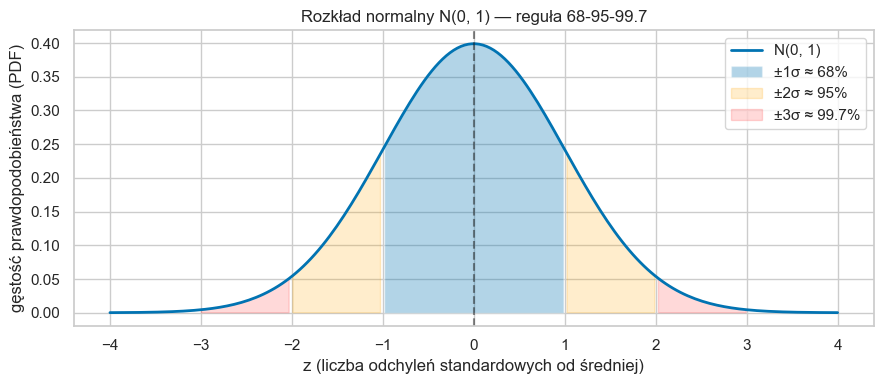

In [6]:
from scipy.stats import norm

# Standardowy rozkład normalny: μ=0, σ=1
x = np.linspace(-4, 4, 200)
y = norm.pdf(x, loc=0, scale=1)  # PDF = Probability Density Function (gęstość prawdopodobieństwa)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x, y, 'b-', linewidth=2, label='N(0, 1)')
ax.fill_between(x, y, where=(np.abs(x) <= 1), alpha=0.3, label='±1σ ≈ 68%')
ax.fill_between(x, y, where=(np.abs(x) <= 2) & (np.abs(x) > 1), alpha=0.2, color='orange', label='±2σ ≈ 95%')
ax.fill_between(x, y, where=(np.abs(x) <= 3) & (np.abs(x) > 2), alpha=0.15, color='red', label='±3σ ≈ 99.7%')
ax.axvline(0, color='k', linestyle='--', alpha=0.5)
ax.set_xlabel('z (liczba odchyleń standardowych od średniej)')
ax.set_ylabel('gęstość prawdopodobieństwa (PDF)')
ax.set_title('Rozkład normalny N(0, 1) — reguła 68-95-99.7')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

**Reguła 68-95-99.7** (znana z W11) — fundament całej intuicji testów:
- ~68% obserwacji w przedziale [μ-σ, μ+σ]
- ~95% w przedziale [μ-2σ, μ+2σ] (dokładniej: ±1.96σ)
- ~99.7% w przedziale [μ-3σ, μ+3σ]

**Skąd 1.96?** To **wartość krytyczna** rozkładu normalnego dla pokrycia 95% — używana jako mnożnik w CI 95% (Sekcja 3) i jako próg w testach z-score.

In [7]:
# Cztery kluczowe operacje na rozkładzie
print('PDF f(0)            =', norm.pdf(0))             # wartość gęstości w punkcie 0
print('CDF F(1.96)         =', norm.cdf(1.96))           # P(Z ≤ 1.96) — 97.5%
print('Wartość krytyczna 95%:', norm.ppf(0.975))         # z* takie że P(Z ≤ z*) = 0.975
print('Losowa próba z N(0,1):', norm.rvs(size=5, random_state=42).round(3))

PDF f(0)            = 0.3989422804014327
CDF F(1.96)         = 0.9750021048517795
Wartość krytyczna 95%: 1.959963984540054
Losowa próba z N(0,1): [ 0.497 -0.138  0.648  1.523 -0.234]


**Ściąga: 4 metody każdego rozkładu w scipy.stats**

| Metoda | Co robi | Przykład |
|--------|---------|----------|
| `.pdf(x)` | Gęstość prawdopodobieństwa w punkcie x (Probability **D**ensity **F**unction) | `norm.pdf(0) = 0.399` |
| `.cdf(x)` | Dystrybuanta: P(X ≤ x) (**C**umulative **D**istribution **F**unction) | `norm.cdf(1.96) = 0.975` |
| `.ppf(p)` | Wartość kwantylowa: x takie że F(x)=p (**P**ercent **P**oint **F**unction, odwrotność CDF) | `norm.ppf(0.975) = 1.96` |
| `.rvs(size=n)` | Losowanie n wartości (**R**andom **V**ariate**S**) | `norm.rvs(size=5)` |

Te 4 metody działają identycznie dla każdego rozkładu: `t`, `chi2`, `f`, `binom`, `poisson`, `expon`, `gamma`, `beta`...

**Skąd 0.975 w `norm.ppf(0.975)` przy 95% CI?** Dla **dwustronnego** przedziału ufności (95%) dzielimy 5% na dwa ogony po 2.5% — szukamy więc wartości krytycznej dla kwantyla `1 − 0.025 = 0.975`. Stąd `norm.ppf(0.975) = 1.96` — magiczna liczba całej statystyki klasycznej.

### 2.2. Centralne Twierdzenie Graniczne (CLT)

**Twierdzenie**: niech X₁, X₂, ..., Xₙ to niezależne zmienne losowe z dowolnego rozkładu o skończonej wariancji σ². Wówczas dla dużych n rozkład średniej z próby x̄ jest **w przybliżeniu normalny**:

$$\bar{X} \sim N\!\left(\mu,\ \dfrac{\sigma^2}{n}\right)\quad\text{czyli}\ \bar{X}\ \text{ma}\ SE=\sigma/\sqrt{n}$$

**Co to znaczy w praktyce**: nawet jeśli dane są skośne (zarobki, czasy reakcji, wartości transakcji), to średnie z dużych prób będą miały kształt dzwonu. Dlatego t-test (oparty na rozkładzie normalnym średniej) działa dla danych nienormalnych — pod warunkiem dostatecznej próby.

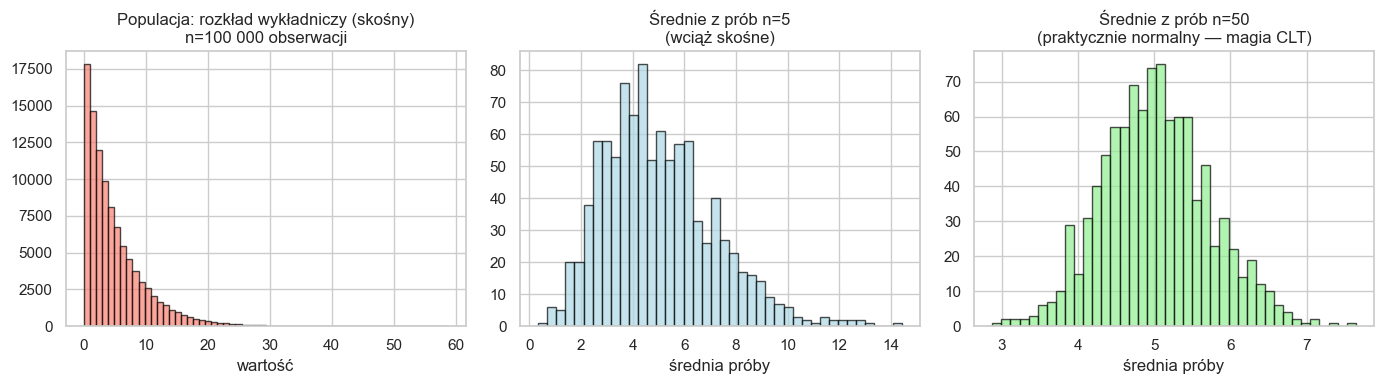

Skośność populacji            : 1.99 (silnie prawoskośna)
Skośność średnich z n=5       : 0.79
Skośność średnich z n=50      : 0.21 (≈ 0, dzwonowy)


In [8]:
np.random.seed(42)

# Bierzemy SILNIE SKOŚNY rozkład — wykładniczy (typowy dla czasów obsługi)
populacja = stats.expon.rvs(scale=5, size=100_000)  # μ=5, mocno prawoskośny

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(populacja, bins=60, color='salmon', edgecolor='black', alpha=0.7)
axes[0].set_title('Populacja: rozkład wykładniczy (skośny)\nn=100 000 obserwacji')
axes[0].set_xlabel('wartość')

# Pobieramy 1000 prób po n=5 i liczymy średnie
srednie_n5 = [np.mean(np.random.choice(populacja, 5)) for _ in range(1000)]
axes[1].hist(srednie_n5, bins=40, color='lightblue', edgecolor='black', alpha=0.7)
axes[1].set_title('Średnie z prób n=5\n(wciąż skośne)')
axes[1].set_xlabel('średnia próby')

# Pobieramy 1000 prób po n=50 i liczymy średnie
srednie_n50 = [np.mean(np.random.choice(populacja, 50)) for _ in range(1000)]
axes[2].hist(srednie_n50, bins=40, color='lightgreen', edgecolor='black', alpha=0.7)
axes[2].set_title('Średnie z prób n=50\n(praktycznie normalny — magia CLT)')
axes[2].set_xlabel('średnia próby')

plt.tight_layout()
plt.show()

print(f'Skośność populacji            : {stats.skew(populacja):.2f} (silnie prawoskośna)')
print(f'Skośność średnich z n=5       : {stats.skew(srednie_n5):.2f}')
print(f'Skośność średnich z n=50      : {stats.skew(srednie_n50):.2f} (≈ 0, dzwonowy)')

**Wniosek z CLT**: niezależnie od kształtu populacji, średnia z próby staje się **normalna** wraz ze wzrostem n. Rule of thumb: **n ≥ 30 wystarcza** dla większości rozkładów (dla skrajnie skośnych może potrzebować więcej).

**Dlaczego to ważne dla wykładu**: cały aparat t-testu, CI dla średniej, testów proporcji opiera się na CLT. Bez CLT musielibyśmy zakładać normalność danych — a w biznesie dane prawie nigdy nie są normalne (zarobki, czasy, wartości — wszystko skośne).

### 2.3. ⚠️ Pułapka mentalna (M5): „t-test wymaga rozkładu normalnego DANYCH”

**NIE.** t-test wymaga normalności **rozkładu próby średniej**, nie samych danych.

- Dla **dużych prób** (n ≥ 30 z każdej grupy) → CLT zapewnia normalność średniej automatycznie. **Możesz używać t-testu nawet dla bardzo skośnych danych.**
- Dla **małych prób** (n < 30) i silnie skośnych danych → CLT może nie zadziałać. Wtedy: test nieparametryczny (Mann-Whitney dla 2 grup niezależnych, Wilcoxon dla sparowanych) — Sekcja 7.

Jak sprawdzić normalność: histogram + **Q-Q plot** (Quantile-Quantile — porównuje kwantyle danych z kwantylami rozkładu normalnego; jeśli punkty leżą na linii — normalność OK).

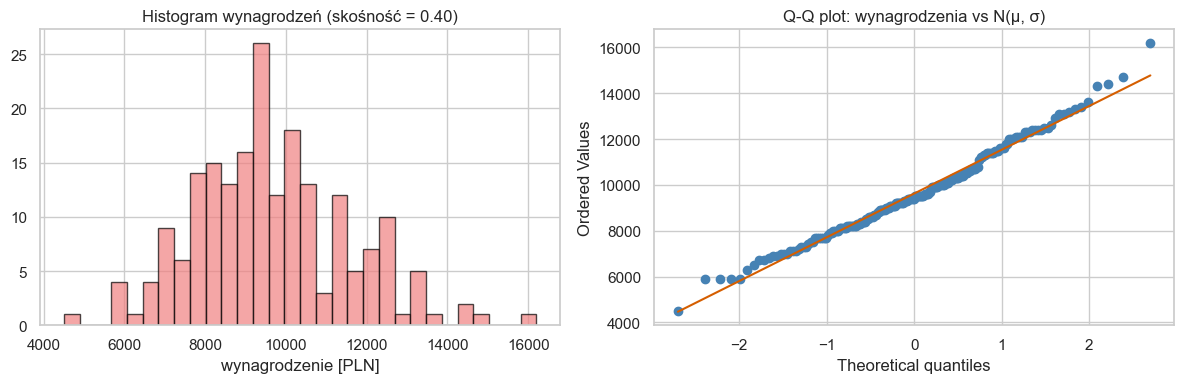

Punkty na końcach (ogony) odbiegają od linii → rozkład prawoskośny.
Mimo to: t-test będzie OK, bo n=200 i CLT dziala (próba duża).


In [9]:
# Q-Q plot dla danych wynagrodzeń (W11 dataset)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(hr['wynagrodzenie'], bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0].set_title(f'Histogram wynagrodzeń (skośność = {stats.skew(hr["wynagrodzenie"]):.2f})')
axes[0].set_xlabel('wynagrodzenie [PLN]')

# Q-Q plot vs rozkład normalny
stats.probplot(hr['wynagrodzenie'], dist='norm', plot=axes[1])
axes[1].set_title('Q-Q plot: wynagrodzenia vs N(μ, σ)')
axes[1].get_lines()[0].set_markerfacecolor('steelblue')
axes[1].get_lines()[0].set_markeredgecolor('steelblue')

plt.tight_layout()
plt.show()

print('Punkty na końcach (ogony) odbiegają od linii → rozkład prawoskośny.')
print(f'Mimo to: t-test będzie OK, bo n=200 i CLT dziala (próba duża).')

## 3. Przedziały ufności (Confidence Interval, CI)

**Estymator z próby** (np. średnia x̄, proporcja p̂) to liczba — ale obarczona niepewnością. CI mówi: *„w jakim przedziale prawdopodobnie leży prawdziwa wartość parametru populacji”*.

**Poprawna definicja (frequentist — *podejście częstościowe*, klasyczna statystyka oparta na powtarzalności eksperymentów; alternatywa to *statystyka bayesowska* z rozkładami apriori, poza zakresem tego kursu)**: gdybyśmy powtórzyli badanie wiele razy, 95% obliczonych CI obejmie prawdziwy parametr populacji.

**Akceptowalna interpretacja biznesowa**: „z 95% pewnością prawdziwa średnia leży w tym przedziale”.

**Niepoprawne (M4)**: „95% danych mieści się w przedziale” (to przedział predykcji, nie ufności).

### 3.1. CI dla średniej — `scipy.stats.t.interval`

Wzór klasyczny: $\bar{x} \pm t^* \cdot \frac{s}{\sqrt{n}}$, gdzie $t^*$ to wartość krytyczna rozkładu t-Studenta dla zadanego poziomu ufności i n-1 stopni swobody (df — degrees of freedom).

In [10]:
# CI 95% dla średniej wartości koszyka w grupie wariant (tylko zakupy)
zakupy_wariant = df[(df['grupa'] == 'wariant') & (df['kupil'] == 1)]['wartosc_koszyka']

n = len(zakupy_wariant)
mean = zakupy_wariant.mean()
std = zakupy_wariant.std(ddof=1)  # ddof=1 → estymator z próby (Bessel correction, TC1 z W11)
se = std / np.sqrt(n)              # SE = Standard Error (błąd standardowy średniej)

# Metoda 1: ręcznie z t.ppf
df_t = n - 1                         # stopnie swobody
t_crit = stats.t.ppf(0.975, df=df_t) # wartość krytyczna dla 95% CI dwustronnego
ci_low_manual = mean - t_crit * se
ci_high_manual = mean + t_crit * se

# Metoda 2: scipy.stats.t.interval (szybciej)
ci_low, ci_high = stats.t.interval(0.95, df=df_t, loc=mean, scale=se)

print(f'n = {n}')
print(f'Średnia koszyka:  {mean:.2f} PLN')
print(f'SE (błąd std)  :  {se:.2f} PLN')
print(f't* (n-1={df_t}) :  {t_crit:.3f}')
print(f'95% CI (ręcznie):  [{ci_low_manual:.2f}, {ci_high_manual:.2f}]')
print(f'95% CI (scipy)  :  [{ci_low:.2f}, {ci_high:.2f}]')

n = 182
Średnia koszyka:  223.12 PLN
SE (błąd std)  :  7.79 PLN
t* (n-1=181) :  1.973
95% CI (ręcznie):  [207.76, 238.48]
95% CI (scipy)  :  [207.76, 238.48]


**Interpretacja biznesowa**: prawdziwa średnia wartość koszyka w wariancie B leży **prawdopodobnie w przedziale obliczonym powyżej** (z 95% pewnością — w sensie powtarzalności badania: ~95% obliczonych CI obejmie prawdziwą wartość). To dużo precyzyjniejsza informacja niż sama średnia punktowa — bo zawiera **niepewność estymatora**.

### 3.2. ⚠️ Pułapka mentalna (M4): „95% CI = 95% danych w przedziale”

**NIE.** CI dotyczy **niepewności estymatora** (średniej / proporcji), nie rozrzutu danych.

**Trzy często mylone pojęcia:**

| Pojęcie | Co opisuje | Wzór skrótowy |
|---------|------------|---------------|
| **Przedział ufności (CI)** | Niepewność średniej / proporcji | x̄ ± t* · SE |
| **Przedział predykcji** | Gdzie spadnie KOLEJNA obserwacja | x̄ ± t* · s · √(1 + 1/n) |
| **Kwartyle / percentyle** | Rozrzut danych w próbie | Q1, Q3, P5, P95 |

Pamiętaj: CI **zwęża się** wraz ze wzrostem n (więcej danych → precyzyjniejsza średnia). Rozrzut danych (std) jest niezależny od n.

**Test interpretacji** — które zdanie jest POPRAWNE dla CI 95% średniej koszyka = [180, 220] PLN?

- ❌ „95% klientów wydaje 180–220 PLN” (to byłby kwartyl/percentyl)
- ❌ „95% szans, że średni koszyk = 200 PLN” (CI nie mówi o pojedynczym punkcie)
- ✅ „Z 95% pewnością prawdziwa średnia leży w przedziale 180–220 PLN” (akceptowalna interpretacja biznesowa)
- ✅ „Gdybyśmy powtórzyli badanie 100 razy, ~95 przedziałów objęłoby prawdziwą średnią” (formalnie najpoprawniejsze)

### 3.3. CI dla proporcji — `statsmodels.stats.proportion`

Dla danych binarnych (0/1 — kupił/nie kupił) używamy innego wzoru. Najczęściej stosowane:
- **Wilson** (lepszy dla małych prób i ekstremalnych proporcji) — domyślny
- **Normal approximation** (klasyczny p̂ ± 1.96·SE, działa dla dużych prób)

In [11]:
from statsmodels.stats.proportion import proportion_confint

# Konwersja kontrol vs wariant
n_kontrol = (df['grupa'] == 'kontrol').sum()
k_kontrol = df[df['grupa'] == 'kontrol']['kupil'].sum()
n_wariant = (df['grupa'] == 'wariant').sum()
k_wariant = df[df['grupa'] == 'wariant']['kupil'].sum()

ci_k = proportion_confint(k_kontrol, n_kontrol, alpha=0.05, method='wilson')
ci_w = proportion_confint(k_wariant, n_wariant, alpha=0.05, method='wilson')

print(f'KONTROL: konwersja = {k_kontrol/n_kontrol:.3%}, 95% CI (Wilson) = [{ci_k[0]:.3%}, {ci_k[1]:.3%}]')
print(f'WARIANT: konwersja = {k_wariant/n_wariant:.3%}, 95% CI (Wilson) = [{ci_w[0]:.3%}, {ci_w[1]:.3%}]')
print()
print('Czy CI się nakładają? Jeśli nie — silny sygnał różnicy. Jeśli tak — formalny test (Sekcja 6 chi²).')

KONTROL: konwersja = 5.240%, 95% CI (Wilson) = [4.433%, 6.184%]
WARIANT: konwersja = 7.280%, 95% CI (Wilson) = [6.326%, 8.365%]

Czy CI się nakładają? Jeśli nie — silny sygnał różnicy. Jeśli tak — formalny test (Sekcja 6 chi²).


### 3.4. Mini-ćwiczenie A — CI dla satysfakcji klientów (CSAT) (worked example)

**Dane**: Pomiar CSAT (Customer Satisfaction Score, ocena 1-10) w próbie n=150 klientów. Średnia = 7.4, std = 1.8. Policz 95% CI dla średniej CSAT.

In [12]:
n_csat = 150
mean_csat = 7.4
std_csat = 1.8
se_csat = std_csat / np.sqrt(n_csat)

ci_csat = stats.t.interval(0.95, df=n_csat - 1, loc=mean_csat, scale=se_csat)
print(f'95% CI dla średniej CSAT: [{ci_csat[0]:.2f}, {ci_csat[1]:.2f}]')
print(f'Szerokość CI = {ci_csat[1] - ci_csat[0]:.2f}')
print(f'Interpretacja: prawdziwy średni CSAT leży prawdopodobnie w {ci_csat[0]:.1f}-{ci_csat[1]:.1f} (z 95% pewnością)')

95% CI dla średniej CSAT: [7.11, 7.69]
Szerokość CI = 0.58
Interpretacja: prawdziwy średni CSAT leży prawdopodobnie w 7.1-7.7 (z 95% pewnością)


### 3.5. Mini-ćwiczenie B — CI dla konwersji infolinii (faded)

**Dane**: infolinia obsłużyła 800 połączeń, 92 zakończone sprzedażą. Policz 95% CI dla wskaźnika konwersji (Wilson).

Uzupełnij brakujące wartości (oznaczone `____`):

In [13]:
n_call = 800
k_call = 92

# Wskazówka: użyj proportion_confint z method='wilson'
ci_call = proportion_confint(k_call, n_call, alpha=0.05, method='wilson')
print(f'Konwersja infolinii: {k_call/n_call:.2%}')
print(f'95% CI: [{ci_call[0]:.2%}, {ci_call[1]:.2%}]')

Konwersja infolinii: 11.50%
95% CI: [9.47%, 13.90%]


### 3.6. Mini-ćwiczenie C — CI dla czasu reakcji helpdesku (independent)

**Dane**: zmierzono czas reakcji helpdesku w próbie 40 ticketów. Średnia = 18.5 min, std = 6.2 min.

**Zadanie do wykonania**: policz 95% CI dla średniego czasu reakcji i odpowiedz: czy SLA „średnio < 20 min” jest na pewno spełnione?

In [14]:
n_help = 40
mean_help = 18.5
std_help = 6.2

se_help = std_help / np.sqrt(n_help)
ci_help = stats.t.interval(0.95, df=n_help - 1, loc=mean_help, scale=se_help)

print(f'95% CI dla średniego czasu reakcji: [{ci_help[0]:.2f}, {ci_help[1]:.2f}] min')
print(f'SLA (< 20 min) {"NA PEWNO spełnione" if ci_help[1] < 20 else "NIEPEWNE — górna granica CI > 20"}')

95% CI dla średniego czasu reakcji: [16.52, 20.48] min
SLA (< 20 min) NIEPEWNE — górna granica CI > 20


## 4. Logika testu hipotez

Test statystyczny to **formalna procedura** sprawdzania, czy obserwowane dane są zgodne z określoną hipotezą. Cała statystyka klasyczna (frequentist) używa **dowodu nie wprost**: zakładamy że nic się nie dzieje (H0), patrzymy jak dziwne są nasze dane przy tym założeniu, i decydujemy czy je odrzucić.

### 4.1. 🔑 TC1: Hipoteza zerowa (H0) i alternatywna (H1)

**H0 (hipoteza zerowa)** — „nic się nie dzieje”, „efektu nie ma”, „grupy są równe”, „średnia = wartość referencyjna”. To **status quo** — co zakładamy, dopóki dane nas nie przekonają inaczej.

**H1 (hipoteza alternatywna)** — to co chcemy udowodnić (lub odrzucić H0 na rzecz). „efekt istnieje”, „grupy się różnią”, „średnia ≠ wartość referencyjna”.

**Logika dowodu nie wprost**: zakładamy że H0 prawdziwa → patrzymy, czy nasze dane są zgodne z tym założeniem → jeśli są bardzo nietypowe (rzadkie pod H0) → odrzucamy H0 na rzecz H1.

**Analogia: sąd.** H0 = „oskarżony niewinny” (domniemanie niewinności). Prokurator (test) musi przedstawić dowody (dane) tak silne, że ławnicy (próg α) odrzucą H0. **Brak odrzucenia ≠ udowodnienie niewinności** — może być za mało dowodów.

**Trzy typy alternatywy H1:**

| Typ | Notacja | Pytanie biznesowe | Parametr scipy |
|-----|---------|-------------------|----------------|
| **Dwustronna** (two-sided) | H1: μ ≠ μ₀ | Czy się różni? (w którąkolwiek stronę) | `alternative='two-sided'` (domyślnie) |
| **Lewostronna** (left-tailed) | H1: μ < μ₀ | Czy jest istotnie mniejsze? | `alternative='less'` |
| **Prawostronna** (right-tailed) | H1: μ > μ₀ | Czy jest istotnie większe? | `alternative='greater'` |

Zasada: **wybierasz przed zobaczeniem danych**. Nie wolno zmieniać alternatywy po obejrzeniu wyniku (to *p-hacking*).

### 4.2. 🔑 TC2: p-value to P(dane | H0), nie P(H0 | dane)

**p-value** = warunkowe prawdopodobieństwo, że zobaczymy nasze dane (lub bardziej skrajne) **GDYBY H0 była prawdziwa**.

```
p-value = P( dane | H0 )    NIE: P( H0 | dane )
             ↑      ↑
          widzimy  zakładamy
```

**Analogia**: czułość testu medycznego (P(pozytywny | chory)) ≠ prawdopodobieństwo choroby przy pozytywnym teście (P(chory | pozytywny)). To dwa różne pytania.

**Przykład interpretacji**:
- `p = 0.03` → „gdyby H0 była prawdziwa, takie albo skrajniejsze dane zobaczylibyśmy w 3% powtórzeń eksperymentu” ✅
- `p = 0.03` → „jest 3% szans, że H0 prawdziwa” ❌ (M1 — odwrotne warunkowanie)
- `p = 0.03` → „jest 97% szans, że H1 prawdziwa” ❌ (M1, wariant)

**Reguła decyzyjna** (Fisher 1925, do dziś standard):
- `p < α` (zwykle α=0.05) → **odrzuć H0** („wynik istotny statystycznie”)
- `p ≥ α` → **brak odrzucenia H0** (NIE: „przyjmij H0”, NIE: „efektu nie ma”)

### 4.3. ⚠️ Pułapka mentalna (M1): „p-value = prawdopodobieństwo, że H0 prawdziwa”

**NIE.** p-value to P(dane | H0), nie P(H0 | dane). To odwrotne warunkowanie wymaga rozkładu apriori (Bayes), którego klasyczny test statystyczny nie zna.

Cytat ASA Statement on p-values (2016):

> *„No single index should substitute for scientific reasoning. (...) Scientific conclusions and business or policy decisions should not be based only on whether a p-value passes a specific threshold.”*

**Polski przekład**: „Żaden pojedynczy wskaźnik nie powinien zastępować rozumowania naukowego. (...) Wnioski naukowe i decyzje biznesowe nie powinny opierać się wyłącznie na tym, czy p-value przekracza określony próg.”

Stąd potrzeba **trójki**: p-value + effect size + CI (TC4, Sekcja 8).

### 4.4. ⚠️ Pułapka mentalna (M2): „p<0.05 = efekt istnieje; p>0.05 = efekt nie istnieje”

**NIE.** Brak odrzucenia H0 nie oznacza, że H0 jest prawdziwa — może być po prostu za mało dowodów (mała próba, niska moc).

**Przykład**: ten sam efekt rzeczywisty (np. wzrost konwersji 5% → 5.5%) da:
- `p = 0.40` przy n=100 (efekt jest, ale niewykryty — niska moc)
- `p = 0.04` przy n=2000 (efekt wykryty)
- `p = 0.0001` przy n=20000 (efekt wykryty bardzo wyraźnie)

**Wniosek**: p-value zależy od TRZECH rzeczy:
1. Wielkości efektu (effect size)
2. Wariancji w danych (std)
3. **Wielkości próby (n)**

Sam fakt że `p > 0.05` nic nie mówi o braku efektu — może być słaba moc testu (TC3, Sekcja 4.6).

### 4.5. 🔑 TC3: Błąd I rodzaju (α) vs Błąd II rodzaju (β) vs Moc (1-β)

Każda decyzja statystyczna może się pomylić na DWA sposoby:

| | **H0 prawdziwa** (efektu nie ma) | **H0 fałszywa** (efekt istnieje) |
|---|---|---|
| **Odrzucamy H0** | ❌ Błąd I rodzaju (α, false positive) | ✅ Poprawne wykrycie (power = 1-β) |
| **Nie odrzucamy H0** | ✅ Poprawne | ❌ Błąd II rodzaju (β, false negative) |

**α** (alpha) — prawdopodobieństwo błędu I rodzaju, czyli odrzucenia H0 mimo że była prawdziwa. **Wybieramy z góry** (zwykle 0.05).

**β** (beta) — prawdopodobieństwo błędu II rodzaju, czyli nieodrzucenia H0 mimo że była fałszywa. Typowo akceptowane β=0.20.

**Power (1-β)** — moc testu = szansa wykrycia efektu, GDY ON ISTNIEJE. Typowo wymagamy power ≥ 0.80.

**Analogia**: alarm pożarowy. False positive (alarm bez pożaru): ewakuacja, koszt. False negative (pożar bez alarmu): śmierć, zniszczenie. **Koszty są asymetryczne** — w teście leków akceptujemy niski α, w A/B test marketingowym konwencja α=0.05, power=0.8.

### 4.6. Power analysis — ile potrzebuję n, żeby wykryć efekt?

**Pytanie biznesowe**: planujemy A/B test. Spodziewamy się efektu (Cohen's d = 0.3 — mały-średni). Ile klientów musi być w każdej grupie, żeby z 80% szansą wykryć efekt przy α=0.05?

Narzędzie: `statsmodels.stats.power.TTestIndPower`

In [15]:
from statsmodels.stats.power import TTestIndPower

power_analysis = TTestIndPower()
n_required = power_analysis.solve_power(effect_size=0.3, alpha=0.05, power=0.80, alternative='two-sided')

print(f'Cohen\'s d = 0.3 (mały-średni efekt)')
print(f'α = 0.05, power = 0.80')
print(f'Wymagane n per grupę: {n_required:.0f}')
print(f'Łącznie: {2*n_required:.0f} obserwacji')

# Czarna magia: dla różnych effect size
print()
print('Wymagane n per grupa dla różnych effect size (α=0.05, power=0.80):')
for d in [0.1, 0.2, 0.3, 0.5, 0.8, 1.0]:
    n = power_analysis.solve_power(effect_size=d, alpha=0.05, power=0.80)
    print(f'  Cohen\'s d = {d}  →  n = {n:>6.0f} per grupa')

Cohen's d = 0.3 (mały-średni efekt)
α = 0.05, power = 0.80
Wymagane n per grupę: 175
Łącznie: 351 obserwacji

Wymagane n per grupa dla różnych effect size (α=0.05, power=0.80):
  Cohen's d = 0.1  →  n =   1571 per grupa
  Cohen's d = 0.2  →  n =    393 per grupa
  Cohen's d = 0.3  →  n =    175 per grupa
  Cohen's d = 0.5  →  n =     64 per grupa
  Cohen's d = 0.8  →  n =     26 per grupa
  Cohen's d = 1.0  →  n =     17 per grupa


**Wnioski biznesowe**:
- Mały efekt (d=0.1) → potrzeba ~1500 klientów per grupa
- Średni (d=0.5) → ~64 per grupa wystarczy
- Duży (d=0.8) → już 26 per grupa wykryje efekt

**Stąd**: ZANIM zaczniesz A/B test, zrób **power analysis** — żeby nie marnować budżetu na za małą próbę (niska moc, false negative).

## 5. t-test — porównywanie średnich

**t-test** (test Studenta — pseudonim Williama Gosseta z Guinness, 1908) — porównuje średnie. Trzy warianty:

| Wariant | Pytanie | Funkcja scipy |
|---------|---------|---------------|
| **1-sample** | Czy średnia próby różni się od WARTOŚCI REFERENCYJNEJ? | `stats.ttest_1samp(data, popmean)` |
| **2-sample independent** | Czy średnie DWÓCH NIEZALEŻNYCH grup się różnią? | `stats.ttest_ind(g1, g2, equal_var=False)` |
| **Paired (sparowany)** | Czy średnia ZMIANY w tej samej próbie jest różna od 0? (przed/po) | `stats.ttest_rel(przed, po)` |

**Ważne (Welch's t-test)**: `equal_var=False` to **Welch's t-test** — wersja niewymagająca równości wariancji w grupach. **Domyślnie używaj go** — jest bezpieczniejszy i lepiej działa dla nierównych grup.

### 5.1. 1-sample t-test — czy średnia ≠ wartość referencyjna

**Pytanie**: czas obsługi naszej infolinii ma być ≤ 5 minut zgodnie z **SLA** (*Service Level Agreement*, umowa o poziomie usługi — formalna gwarancja jakości obsługi). Czy próba 50 połączeń (średnia 5.4 min, std 1.8) pokazuje istotne przekroczenie SLA?

In [16]:
np.random.seed(1)
czas_infolinii = np.random.gamma(shape=6, scale=0.95, size=50)
print(f'Próba: n={len(czas_infolinii)}, średnia={czas_infolinii.mean():.2f} min, std={czas_infolinii.std(ddof=1):.2f}')

# H0: μ = 5 min (SLA spełnione)
# H1: μ > 5 min (SLA przekroczone) — alternatywna jednostronna
result = stats.ttest_1samp(czas_infolinii, popmean=5, alternative='greater')

print(f'\nt-statistic = {result.statistic:.3f}')
print(f'p-value     = {result.pvalue:.4f}')
print(f'df          = {result.df:.0f}')

if result.pvalue < 0.05:
    print('Decyzja: ODRZUĆ H0. Średni czas istotnie > 5 min — SLA przekroczone.')
else:
    print('Decyzja: brak podstaw do odrzucenia. Nie wykryto istotnego przekroczenia.')

Próba: n=50, średnia=5.72 min, std=2.23

t-statistic = 2.290
p-value     = 0.0132
df          = 49
Decyzja: ODRZUĆ H0. Średni czas istotnie > 5 min — SLA przekroczone.


**Uwaga**: użyliśmy `alternative='greater'` (jednostronny test), bo pytanie biznesowe to TYLKO „czy przekracza SLA”, nie „czy się różni od 5”. Test jednostronny ma większą moc dla tego konkretnego kierunku.

### 5.2. 2-sample independent t-test — porównanie dwóch grup

**Pytanie**: czy dział IT zarabia istotnie więcej niż HR? (powrót do danych z W11)

In [17]:
it = hr[hr['dzial'] == 'IT']['wynagrodzenie']
hr_dept = hr[hr['dzial'] == 'HR']['wynagrodzenie']

print(f'IT  : n={len(it)},  mean={it.mean():.0f} PLN,  std={it.std(ddof=1):.0f}')
print(f'HR  : n={len(hr_dept)},  mean={hr_dept.mean():.0f} PLN,  std={hr_dept.std(ddof=1):.0f}')

# Welch's t-test (equal_var=False) — bezpieczniejszy domyślnie
result = stats.ttest_ind(it, hr_dept, equal_var=False, alternative='two-sided')

print(f'\nWelch\'s t-test:')
print(f'  t-statistic = {result.statistic:.3f}')
print(f'  p-value     = {result.pvalue:.6f}')
print(f'  df          = {result.df:.1f}')

diff = it.mean() - hr_dept.mean()
pooled_std = np.sqrt((it.var(ddof=1) + hr_dept.var(ddof=1)) / 2)
cohens_d = diff / pooled_std
print(f'\nEffect size:')
print(f'  Różnica średnich = {diff:.0f} PLN')
print(f'  Cohen\'s d       = {cohens_d:.2f}  ({"duży" if abs(cohens_d) > 0.8 else "średni" if abs(cohens_d) > 0.5 else "mały-średni"})')

IT  : n=66,  mean=10868 PLN,  std=1824
HR  : n=24,  mean=8354 PLN,  std=1622

Welch's t-test:
  t-statistic = 6.284
  p-value     = 0.000000
  df          = 45.6

Effect size:
  Różnica średnich = 2514 PLN
  Cohen's d       = 1.46  (duży)


**Interpretacja**: `p << 0.001` → odrzucamy H0. Różnica średnich wynagrodzeń IT vs HR jest istotna statystycznie. **Cohen's d** mówi nam dodatkowo, że to **duży effect size** (d > 0.8) — czyli różnica jest też istotna biznesowo.

**Cohen's d** (Cohen 1988) — standaryzowana różnica średnich:
- |d| < 0.2 — efekt znikomy
- 0.2 ≤ |d| < 0.5 — efekt mały
- 0.5 ≤ |d| < 0.8 — efekt średni
- |d| ≥ 0.8 — efekt duży

### 5.3. Paired t-test (sparowany) — przed/po dla tej samej próby

**Pytanie**: 30 pracowników przeszło szkolenie. Mierzymy czas obsługi klienta PRZED i PO szkoleniu. Czy szkolenie skróciło średni czas?

**Kluczowe**: te same osoby przed i po → **pary**. Nie 60 niezależnych pomiarów — 30 par.

In [18]:
np.random.seed(11)
n_szk = 30
czas_przed = np.random.gamma(shape=8, scale=1, size=n_szk).round(2)  # ~8 min
# po szkoleniu: ~70% pracowników się poprawia, reszta bez zmian
poprawa = np.where(np.random.rand(n_szk) < 0.7,
                   np.random.gamma(2, 0.4, n_szk),
                   np.random.normal(0, 0.3, n_szk))
czas_po = (czas_przed - poprawa).clip(2, 20).round(2)

print(f'Przed: mean={czas_przed.mean():.2f} min, std={czas_przed.std(ddof=1):.2f}')
print(f'Po   : mean={czas_po.mean():.2f} min, std={czas_po.std(ddof=1):.2f}')
print(f'Różnica średnich: {(czas_po - czas_przed).mean():.2f} min')

# Paired t-test, alternatywa: po < przed (szkolenie skraca)
result = stats.ttest_rel(czas_po, czas_przed, alternative='less')
print(f'\nPaired t-test (alternatywa: po < przed):')
print(f'  t = {result.statistic:.3f},  p = {result.pvalue:.4f}')

if result.pvalue < 0.05:
    print('  Decyzja: ODRZUĆ H0. Szkolenie istotnie skróciło czas.')
else:
    print('  Decyzja: brak podstaw — nie wykryto istotnego efektu.')

Przed: mean=7.86 min, std=2.46
Po   : mean=7.28 min, std=2.28
Różnica średnich: -0.58 min

Paired t-test (alternatywa: po < przed):
  t = -5.574,  p = 0.0000
  Decyzja: ODRZUĆ H0. Szkolenie istotnie skróciło czas.


**Dlaczego paired, nie independent?** Bo eliminujemy zmienność MIĘDZY osobami (Anna jest szybsza niż Bartek niezależnie od szkolenia). Mierzymy tylko zmianę WEWNĄTRZ osoby — to dużo mocniejszy test.

**Reguła**: jeśli masz **te same jednostki** przed/po, w dwóch warunkach (lewe oko / prawe oko) — używaj **paired**. Niezależne grupy (kontrol vs wariant w A/B) → **independent**.

### 5.4. Mini-ćwiczenie A (worked) — t-test wartości koszyka kontrol vs wariant

**Pytanie**: czy średnia wartość koszyka (DLA KUPUJĄCYCH) jest wyższa w wariancie niż w kontroli?

In [19]:
koszyki_kontrol = df[(df['grupa'] == 'kontrol') & (df['kupil'] == 1)]['wartosc_koszyka']
koszyki_wariant = df[(df['grupa'] == 'wariant') & (df['kupil'] == 1)]['wartosc_koszyka']

print(f'KONTROL: n={len(koszyki_kontrol)}, mean={koszyki_kontrol.mean():.2f} PLN')
print(f'WARIANT: n={len(koszyki_wariant)}, mean={koszyki_wariant.mean():.2f} PLN')

result = stats.ttest_ind(koszyki_wariant, koszyki_kontrol, equal_var=False, alternative='greater')
print(f'\nWelch\'s t-test (H1: wariant > kontrol):')
print(f'  t = {result.statistic:.3f},  p = {result.pvalue:.4f}')

KONTROL: n=131, mean=188.11 PLN
WARIANT: n=182, mean=223.12 PLN

Welch's t-test (H1: wariant > kontrol):
  t = 3.097,  p = 0.0011


### 5.5. Mini-ćwiczenie B (faded) — t-test czasu na stronie

**Pytanie**: czy czas spędzony na stronie różni się między grupami (test dwustronny)?

Uzupełnij szablon:

In [20]:
czas_kontrol = df[df['grupa'] == 'kontrol']['czas_na_stronie']
czas_wariant = df[df['grupa'] == 'wariant']['czas_na_stronie']

# Wskazówka: equal_var=False (Welch), alternative='two-sided'
result = stats.ttest_ind(czas_kontrol, czas_wariant, equal_var=False, alternative='two-sided')
print(f'Welch\'s t-test (czas na stronie):')
print(f'  t = {result.statistic:.3f},  p = {result.pvalue:.6f}')
print(f'  Średnie: kontrol={czas_kontrol.mean():.1f} s, wariant={czas_wariant.mean():.1f} s')

Welch's t-test (czas na stronie):
  t = -9.566,  p = 0.000000
  Średnie: kontrol=66.4 s, wariant=77.5 s


### 5.6. Mini-ćwiczenie C (independent) — t-test 1-próbkowy

**Pytanie**: Plan benchmarkowy zakładał, że średnie wynagrodzenie w dziale Marketing wynosi 8500 PLN (bazowo 7500 PLN + premia za staż ~1000 PLN). Czy nasze dane to potwierdzają (n=200 dataset HR z W11)?

**Zadanie do wykonania**: napisz t-test 1-sample dla działu Marketing przeciwko wartości 8500 PLN (oczekiwany benchmark z planu HR). Test dwustronny.

In [21]:
marketing = hr[hr['dzial'] == 'Marketing']['wynagrodzenie']
result = stats.ttest_1samp(marketing, popmean=8500, alternative='two-sided')

print(f'Marketing: n={len(marketing)}, mean={marketing.mean():.0f} PLN')
print(f't = {result.statistic:.3f}, p = {result.pvalue:.4f}')
print(f'{"ODRZUĆ H0 — średnia ≠ 8500" if result.pvalue < 0.05 else "Brak podstaw do odrzucenia — średnia ≈ 8500 (zgodna z planem)"}')

Marketing: n=41, mean=8998 PLN


t = 2.728, p = 0.0094
ODRZUĆ H0 — średnia ≠ 8500


## 6. Test chi-kwadrat (χ²) — niezależność i zgodność

**chi-kwadrat** (chi-squared, χ²) — test dla **zmiennych kategorialnych** (płeć, segment, kategoria produktu). Dwa najważniejsze warianty:

1. **Test niezależności** (`chi2_contingency`) — czy DWIE zmienne kategorialne są zależne? (np. „czy grupa A/B wpływa na konwersję kupił/nie kupił?”)
2. **Test zgodności** (`chisquare`) — czy obserwowane częstości pasują do oczekiwanego rozkładu? (np. „czy kostka jest fair?”)

### 6.1. Test niezależności — A/B test konwersji

**Pytanie**: czy grupa (kontrol/wariant) wpływa na konwersję (kupił/nie kupił)? Budujemy **tabelę kontyngencji 2×2** i liczymy chi².

In [22]:
# Tabela kontyngencji: 2 grupy × 2 outcome
kontyngencja = pd.crosstab(df['grupa'], df['kupil'], margins=False)
kontyngencja.columns = ['nie_kupil', 'kupil']
print('Tabela kontyngencji:')
print(kontyngencja)

chi2, p, dof, expected = stats.chi2_contingency(kontyngencja)
print(f'\nchi² = {chi2:.3f}')
print(f'p    = {p:.4f}')
print(f'df   = {dof}')
print(f'\nOczekiwane częstości (gdyby H0 prawdziwa):')
print(pd.DataFrame(expected.round(1), index=kontyngencja.index, columns=kontyngencja.columns))

if p < 0.05:
    print('\nDecyzja: ODRZUĆ H0. Grupa wpływa na konwersję — kampania działa.')
else:
    print('\nDecyzja: brak podstaw — nie wykryto wpływu kampanii.')

Tabela kontyngencji:
         nie_kupil  kupil
grupa                    
kontrol       2369    131
wariant       2318    182

chi² = 8.521
p    = 0.0035
df   = 1

Oczekiwane częstości (gdyby H0 prawdziwa):


         nie_kupil  kupil
grupa                    
kontrol     2343.5  156.5
wariant     2343.5  156.5

Decyzja: ODRZUĆ H0. Grupa wpływa na konwersję — kampania działa.


**Cramér's V** — uzupełnia chi² o **siłę zależności** (analogicznie jak Cohen's d uzupełnia t-test). Wartości:
- V < 0.1 — efekt znikomy
- 0.1 ≤ V < 0.3 — efekt mały
- 0.3 ≤ V < 0.5 — efekt średni
- V ≥ 0.5 — efekt duży

In [23]:
def cramers_v(chi2, n, table_shape):
    """Cramér's V: pierwiastek z chi² / (n * min(k-1, r-1))"""
    r, k = table_shape
    return np.sqrt(chi2 / (n * min(r-1, k-1)))

n_total = kontyngencja.values.sum()
v = cramers_v(chi2, n_total, kontyngencja.shape)

print(f'n total       = {n_total}')
print(f'chi²          = {chi2:.3f}')
print(f'p-value       = {p:.4f}')
print(f'Cramér\'s V   = {v:.3f}  ({"znikomy" if v < 0.1 else "mały" if v < 0.3 else "średni"})')

n total       = 5000
chi²          = 8.521
p-value       = 0.0035
Cramér's V   = 0.041  (znikomy)


### 6.2. ⚠️ Pułapka mentalna (M7): „chi² to test korelacji”

**NIE.** chi² testuje **niezależność** dwóch zmiennych KATEGORIALNYCH — TAK/NIE, czy są zależne. **Nie mierzy siły ani kierunku**.

| Pytanie | Narzędzie | Skala |
|---------|-----------|-------|
| Czy zmienne ciągłe są liniowo zależne? | Pearson (W11) | -1 do +1 (siła i kierunek) |
| Czy zmienne ciągłe są monotonicznie zależne? | Spearman (W11) | -1 do +1 |
| Czy zmienne kategorialne są zależne (TAK/NIE)? | chi² + Cramér's V | p-value + V (0 do 1, tylko siła) |

**Wniosek**: dla kategorialnych dodawaj zawsze **Cramér's V** obok chi² — żeby raport zawierał istotność I siłę.

### 6.3. Niezależność z segmentem klienta

**Pytanie**: czy segment klienta (nowy / powracający) jest zależny od grupy (kontrol / wariant)? Powinno być NIEZALEŻNE (randomizacja A/B losuje klientów do grup).

In [24]:
kontyngencja_seg = pd.crosstab(df['grupa'], df['segment'])
print('Tabela kontyngencji grupa × segment:')
print(kontyngencja_seg)

chi2_seg, p_seg, dof_seg, _ = stats.chi2_contingency(kontyngencja_seg)
v_seg = cramers_v(chi2_seg, kontyngencja_seg.values.sum(), kontyngencja_seg.shape)

print(f'\nchi² = {chi2_seg:.3f},  p = {p_seg:.4f},  Cramér\'s V = {v_seg:.3f}')

if p_seg < 0.05:
    print('⚠️ Segment ZALEŻY od grupy — randomizacja A/B się nie udała! (sygnał problemu metodologicznego)')
else:
    print('OK: segment NIEZALEŻNY od grupy — randomizacja A/B OK.')

Tabela kontyngencji grupa × segment:
segment  nowy  powracajacy
grupa                     
kontrol  1613          887
wariant  1370         1130

chi² = 48.668,  p = 0.0000,  Cramér's V = 0.099
⚠️ Segment ZALEŻY od grupy — randomizacja A/B się nie udała! (sygnał problemu metodologicznego)


**Uwaga metodologiczna**: w naszym dataset symulowaliśmy lekką różnicę segmentów (65% vs 55% nowych) — celowo, żeby pokazać że randomizacja w realnym świecie czasem zawodzi. Sprawdzenie chi² **przed** głównymi testami to dobra praktyka — wykrywa selection bias.

**Spaced retrieval z W11**: korelacja ≠ przyczynowość. **Randomizacja** to sposób ustalenia przyczynowości — losowy przydział do grup eliminuje wpływ zmiennych ukrytych.

### 6.4. Test zgodności (goodness-of-fit) — `chisquare`

**Pytanie**: rozkład wizyt klientów w 5 dniach tygodnia powinien być równomierny (po 20% każdy dzień). Obserwujemy faktyczne wizyty. Czy dane pasują do oczekiwanego rozkładu?

In [25]:
# Faktyczne wizyty w pn-pt
wizyty = np.array([85, 92, 110, 105, 108])  # 500 łącznie
oczekiwane = np.full(5, wizyty.sum() / 5)

result = stats.chisquare(wizyty, f_exp=oczekiwane)
print('Wizyty po dniach (pn-pt):', wizyty)
print(f'Oczekiwane (równomierne):  {oczekiwane.astype(int)}')
print(f'\nchi² = {result.statistic:.3f}, p = {result.pvalue:.4f}')

if result.pvalue < 0.05:
    print('ODRZUĆ H0: rozkład wizyt różni się od równomiernego — niektóre dni mają większy ruch.')
else:
    print('Brak podstaw — wizyty są w przybliżeniu równomierne.')

Wizyty po dniach (pn-pt): [ 85  92 110 105 108]
Oczekiwane (równomierne):  [100 100 100 100 100]

chi² = 4.780, p = 0.3106
Brak podstaw — wizyty są w przybliżeniu równomierne.


## 7. Jaki test wybrać? — Drzewo decyzyjne

Najczęściej zadawane pytanie po wykładzie: *„jaki test wybrać do moich danych?”*. Odpowiedź zależy od **trzech rzeczy**:

1. **Typu danych** (ciągłe vs kategorialne)
2. **Liczby grup** (1 vs 2 vs więcej)
3. **Założeń** (normalność, równość wariancji, sparowanie)

Drzewo decyzyjne dla najczęstszych przypadków:

```mermaid
graph TD
    A["Jakie dane?"] --> B["Ciągłe<br/>wartość liczbowa"]
    A --> C["Kategorialne<br/>etykieta / klasa"]
    B --> D["Ile grup?"]
    D --> E["1 grupa vs<br/>wartość referencyjna"]
    D --> F["2 grupy"]
    D --> G["3+ grupy → ANOVA<br/>poza zakresem W12"]
    E --> H["Normalność OK<br/>lub n≥30 (CLT)"]
    H -->|TAK| I["ttest_1samp"]
    H -->|NIE| J["Wilcoxon signed-rank"]
    F --> K["Czy SPAROWANE?"]
    K -->|TAK przed/po| L["Normalność OK?"]
    K -->|NIE niezależne| M["Normalność OK<br/>w obu grupach?"]
    L -->|TAK| N["ttest_rel"]
    L -->|NIE| O["Wilcoxon"]
    M -->|TAK| P["ttest_ind<br/>equal_var=False (Welch)"]
    M -->|NIE| Q["Mann-Whitney U"]
    C --> R["chi2_contingency<br/>niezależność"]
    C --> S["chisquare<br/>zgodność z rozkładem"]
```

### 7.1. Testy nieparametryczne — Mann-Whitney i Wilcoxon

Gdy n małe (< 30) i dane silnie skośne — nie używaj t-testu, użyj testu opartego na **rangach** (rank-based).

| Sytuacja | Test parametryczny | Test nieparametryczny |
|----------|--------------------|-----------------------|
| 1-sample (mediana vs wartość) | `ttest_1samp` | `wilcoxon` (na różnicach od wartości) |
| 2-sample independent | `ttest_ind` | `mannwhitneyu` |
| 2-sample paired | `ttest_rel` | `wilcoxon` |

In [26]:
# Mała próba, silnie skośne dane — porównujemy z t-testem i Mann-Whitneyem
np.random.seed(33)
grupa1 = stats.expon.rvs(scale=10, size=15)  # n=15, skośny
grupa2 = stats.expon.rvs(scale=14, size=15)  # n=15, skośny, większa średnia

t_result = stats.ttest_ind(grupa1, grupa2, equal_var=False)
mw_result = stats.mannwhitneyu(grupa1, grupa2, alternative='two-sided')

print(f'Welch\'s t-test    : t = {t_result.statistic:.2f}, p = {t_result.pvalue:.4f}')
print(f'Mann-Whitney U    : U = {mw_result.statistic:.1f}, p = {mw_result.pvalue:.4f}')
print('Skośność grupa1:', stats.skew(grupa1).round(2))
print('Skośność grupa2:', stats.skew(grupa2).round(2))
print('\nPrzy małej próbie i skośnych danych — Mann-Whitney jest BEZPIECZNIEJSZY niż t-test.')

Welch's t-test    : t = -1.25, p = 0.2234
Mann-Whitney U    : U = 82.0, p = 0.2134
Skośność grupa1: 1.47
Skośność grupa2: 1.45

Przy małej próbie i skośnych danych — Mann-Whitney jest BEZPIECZNIEJSZY niż t-test.


### 7.2. ⚠️ Pułapka mentalna (M6): „A/B test wymaga ogromnej próby”

**NIE.** Wymagane n zależy od oczekiwanego **effect size**. Dla dużych efektów wystarczy mała próba; dla małych — potrzebne tysiące.

In [27]:
power_analysis = TTestIndPower()
print('Wymagane n per grupa dla różnych scenariuszy A/B (α=0.05, power=0.80):')
print()
scenarios = [
    ('mały efekt (drobna optymalizacja UI)', 0.1, '~1600'),
    ('mały-średni (zmiana kolorystyki CTA)', 0.3, '~175'),
    ('średni (przebudowa landing page)', 0.5, '~64'),
    ('duży (nowa propozycja wartości)', 0.8, '~26'),
]
for opis, d, _ in scenarios:
    n = power_analysis.solve_power(effect_size=d, alpha=0.05, power=0.80)
    print(f'  {opis:50s}  d={d}  →  n={n:.0f} per grupa')

Wymagane n per grupa dla różnych scenariuszy A/B (α=0.05, power=0.80):

  mały efekt (drobna optymalizacja UI)                d=0.1  →  n=1571 per grupa
  mały-średni (zmiana kolorystyki CTA)                d=0.3  →  n=175 per grupa
  średni (przebudowa landing page)                    d=0.5  →  n=64 per grupa
  duży (nowa propozycja wartości)                     d=0.8  →  n=26 per grupa


**Wniosek**: planuj n PRZED testem, na podstawie spodziewanego effect size. Niska próba = niska moc = false negative (porzucisz dobrą kampanię).

### Złota zasada wyboru testu

1. **Zacznij od wykresu** (histogram, boxplot — W09/W10)
2. **Sprawdź założenia** (normalność = Q-Q plot, skośność = `stats.skew`)
3. **Wybierz test** zgodnie z drzewem
4. **Zrób power analysis** PRZED zbieraniem danych
5. **Raportuj trójką**: p-value + effect size + CI

### 🔑 TC4: Trójka raportowa (p-value + effect size + CI) — nie sama liczba

**Analogia: prognoza pogody.**
- „Padać będzie” (p-value: tak/nie — jest efekt?)
- „Padać będzie 5 mm” (effect size — ilość)
- „Padać będzie 4-6 mm” (95% CI — niepewność prognozy)

Z jedną liczbą wiesz tylko TAK/NIE. **Trójka** pozwala zdecydować — parasol czy płaszcz przeciwdeszczowy?

```
Stara forma raportu (NIE wystarcza):
   „p < 0.05, efekt istnieje”

Trójka raportowa (PROFESJONALNA):
   różnica średnich = 0.7 min     ← effect size (jak duży)
   95% CI = [0.2, 1.2] min         ← precyzja (niepewność)
   p-value = 0.012                  ← istotność (tak/nie)
   Cohen's d = 0.35 (mały-średni)   ← standaryzowany effect size

Decyzja: „Czas obsługi spadł średnio o 0.7 min (95% CI [0.2, 1.2],
         p=0.012, Cohen's d=0.35). Statystycznie istotne, efekt
         średni — warto wdrożyć.”
```

Trzymamy tej zasady **do końca wykładu** i **w każdym raporcie A/B** w karierze analityka.

## 8. KULMINACJA — Raport A/B test dla zarządu

Czas posłużyć się wszystkimi narzędziami razem. Robimy **kompletny raport A/B testu** kampanii e-commerce z naszego datasetu. Trójka:

1. **p-value** — czy efekt istnieje?
2. **effect size** (różnica + Cohen's d / względna różnica) — jak duży?
3. **95% CI** — jak precyzyjnie zmierzone?

### 8.1. Raport: konwersja (kupił / nie kupił)

In [28]:
# Pełna analiza konwersji
k_kontrol_n = (df['grupa'] == 'kontrol').sum()
k_kontrol_k = df[df['grupa'] == 'kontrol']['kupil'].sum()
k_wariant_n = (df['grupa'] == 'wariant').sum()
k_wariant_k = df[df['grupa'] == 'wariant']['kupil'].sum()

p_kontrol = k_kontrol_k / k_kontrol_n
p_wariant = k_wariant_k / k_wariant_n
diff = p_wariant - p_kontrol
rel_diff = diff / p_kontrol

# CI dla różnicy proporcji (statsmodels)
from statsmodels.stats.proportion import confint_proportions_2indep
ci_diff = confint_proportions_2indep(k_wariant_k, k_wariant_n, k_kontrol_k, k_kontrol_n,
                                      method='wald')

# p-value z chi²
table = [[k_kontrol_k, k_kontrol_n - k_kontrol_k],
         [k_wariant_k, k_wariant_n - k_wariant_k]]
chi2, p_value, _, _ = stats.chi2_contingency(table)

print('=== RAPORT A/B: KONWERSJA ===')
print(f'KONTROL: {p_kontrol:.2%} ({k_kontrol_k}/{k_kontrol_n})')
print(f'WARIANT: {p_wariant:.2%} ({k_wariant_k}/{k_wariant_n})')
print(f'\nEFFECT SIZE:')
print(f'  Różnica bezwzględna: {diff*100:+.2f} pp (punkty procentowe)')
print(f'  Różnica względna   : {rel_diff:+.1%}')
print(f'\n95% CI dla różnicy proporcji: [{ci_diff[0]*100:+.2f} pp, {ci_diff[1]*100:+.2f} pp]')
print(f'\nISTOTNOŚĆ:')
print(f'  chi²    = {chi2:.3f}')
print(f'  p-value = {p_value:.5f}')
print(f'  Decyzja: {"ODRZUĆ H0 — wariant ISTOTNIE lepszy" if p_value < 0.05 else "BRAK ODRZUCENIA — niewystarczające dowody"}')

=== RAPORT A/B: KONWERSJA ===
KONTROL: 5.24% (131/2500)
WARIANT: 7.28% (182/2500)

EFFECT SIZE:
  Różnica bezwzględna: +2.04 pp (punkty procentowe)
  Różnica względna   : +38.9%

95% CI dla różnicy proporcji: [+0.70 pp, +3.38 pp]

ISTOTNOŚĆ:
  chi²    = 8.521
  p-value = 0.00351
  Decyzja: ODRZUĆ H0 — wariant ISTOTNIE lepszy


### 8.2. Raport: wartość koszyka (tylko zakupy)

In [29]:
koszyk_kontrol = df[(df['grupa'] == 'kontrol') & (df['kupil'] == 1)]['wartosc_koszyka']
koszyk_wariant = df[(df['grupa'] == 'wariant') & (df['kupil'] == 1)]['wartosc_koszyka']

# Welch's t-test
tt = stats.ttest_ind(koszyk_wariant, koszyk_kontrol, equal_var=False, alternative='two-sided')

# Cohen's d
pooled_var = (koszyk_kontrol.var(ddof=1) + koszyk_wariant.var(ddof=1)) / 2
d = (koszyk_wariant.mean() - koszyk_kontrol.mean()) / np.sqrt(pooled_var)

# CI dla różnicy średnich
diff_mean = koszyk_wariant.mean() - koszyk_kontrol.mean()
se_diff = np.sqrt(koszyk_wariant.var(ddof=1)/len(koszyk_wariant) + koszyk_kontrol.var(ddof=1)/len(koszyk_kontrol))
df_welch = tt.df
t_crit = stats.t.ppf(0.975, df=df_welch)
ci_low = diff_mean - t_crit * se_diff
ci_high = diff_mean + t_crit * se_diff

print('=== RAPORT A/B: WARTOŚĆ KOSZYKA ===')
print(f'KONTROL: mean = {koszyk_kontrol.mean():.2f} PLN  (n={len(koszyk_kontrol)})')
print(f'WARIANT: mean = {koszyk_wariant.mean():.2f} PLN  (n={len(koszyk_wariant)})')
print(f'\nEFFECT SIZE:')
print(f'  Różnica średnich = {diff_mean:+.2f} PLN')
print(f'  Cohen\'s d       = {d:.3f}  ({"duży" if abs(d) > 0.8 else "średni" if abs(d) > 0.5 else "mały-średni" if abs(d) > 0.2 else "znikomy"})')
print(f'\n95% CI dla różnicy średnich: [{ci_low:+.2f}, {ci_high:+.2f}] PLN')
print(f'\nISTOTNOŚĆ:')
print(f'  t = {tt.statistic:.3f},  p = {tt.pvalue:.4f}')
print(f'  Decyzja: {"ODRZUĆ H0" if tt.pvalue < 0.05 else "BRAK PODSTAW DO ODRZUCENIA"}')

=== RAPORT A/B: WARTOŚĆ KOSZYKA ===
KONTROL: mean = 188.11 PLN  (n=131)
WARIANT: mean = 223.12 PLN  (n=182)

EFFECT SIZE:
  Różnica średnich = +35.01 PLN
  Cohen's d       = 0.352  (mały-średni)

95% CI dla różnicy średnich: [+12.76, +57.25] PLN

ISTOTNOŚĆ:
  t = 3.097,  p = 0.0021
  Decyzja: ODRZUĆ H0


### 8.3. ⚠️ Pułapka mentalna (M3): „istotność statystyczna = istotność praktyczna”

**NIE.** Istotność statystyczna mówi tylko, czy efekt jest **odróżnialny od szumu**. Istotność praktyczna (biznesowa) mówi, czy efekt jest **warty wdrożenia**.

**Przykład**: wzrost konwersji 5.00% → 5.05% przy n=50 000 da `p < 0.001` (statystycznie super istotne), ale **+1% względnie** to mikroskopijny efekt — może być za mało na koszt wdrożenia. W naszej Sekcji 0 Firma A pokazała ten sam mechanizm: p=0.0348 przy +9.5% efekcie — istotne, ale skromne biznesowo.

**Reguła**: zawsze sprawdź czy effect size jest **biznesowo wystarczający**, a nie tylko statystycznie istotny.

### 8.4. Decyzja biznesowa — szablon

Jak pisać raport A/B dla zarządu (1 paragraf):

> *„Kampania wariantu B zwiększyła konwersję z [X]% do [Y]% (różnica [+Δ pp], **względnie +[Z]%**, 95% CI dla różnicy: [a, b] pp). Test chi² wskazuje, że efekt jest istotny statystycznie (chi²=[c], p=[d]). Dodatkowo średnia wartość koszyka wzrosła z [X] PLN do [Y] PLN (Cohen's d=[e] — efekt [mały/średni/duży]). **Rekomendacja: wdrożyć / nie wdrożyć / kontynuować test na większej próbie**, ponieważ [powód: koszt wdrożenia / istotność biznesowa / niepewność].”*

**Trzy reguły dobrego raportu A/B:**
1. **Trójka zawsze razem**: p + effect + CI
2. **Decyzja biznesowa**, nie tylko liczby — „rekomendujemy / nie rekomendujemy”
3. **Wyjaśnienie kontekstu** — koszt wdrożenia vs spodziewany zysk

## 9. Pułapki Pythona / scipy.stats

Siedem pułapek, których warto unikać przy testach statystycznych w Pythonie.

### Pułapka 1: `equal_var=True` to DOMYŚLNA wartość w scipy

`stats.ttest_ind(g1, g2)` domyślnie zakłada **równość wariancji** (klasyczny Student's t-test). To często fałszywe założenie. **Bezpieczniej zawsze podaj `equal_var=False`** — to **Welch's t-test**, który nie wymaga równych wariancji.

```python
# ⚠️  ŹLE — może dać błędny wynik dla nierównych wariancji
stats.ttest_ind(g1, g2)

# ✅  OK — Welch's t-test, bezpieczniejszy domyślnie
stats.ttest_ind(g1, g2, equal_var=False)
```

### Pułapka 2: `alternative='two-sided'` domyślnie

Domyślnie wszystkie t-testy w scipy są **dwustronne**. Jeśli pytanie biznesowe ma KIERUNEK (np. „czy wariant jest LEPSZY niż kontrol”), użyj `alternative='greater'` lub `'less'` — test jednostronny ma większą moc.

```python
# H1: wariant > kontrol
stats.ttest_ind(wariant, kontrol, alternative='greater', equal_var=False)
```

**Uwaga**: wybór alternatywy przed zobaczeniem danych — inaczej to *p-hacking*.

### Pułapka 3: NaN psują wynik — `nan_policy='omit'`

Domyślnie scipy zwraca `nan` jeśli w danych są NaN. Użyj `nan_policy='omit'` żeby je pominąć.

```python
stats.ttest_ind(grupa1, grupa2, equal_var=False, nan_policy='omit')
```

**Spaced retrieval (W07)**: pamiętaj jak czyścić NaN — `dropna()`, `fillna()`.

### Pułapka 4: `ddof=0` (numpy domyślnie) vs `ddof=1` (próba)

**Ten sam błąd, co w W11.** `np.std(arr)` używa `ddof=0` (populacja), pandas `Series.std()` używa `ddof=1` (próba — Bessel correction). Dane to zwykle PRÓBA, więc używaj `ddof=1`.

```python
arr = np.array([1, 2, 3, 4, 5])
np.std(arr)         # ddof=0 → 1.414 (std populacji)
np.std(arr, ddof=1)  # ddof=1 → 1.581 (std próby) — to chcesz
pd.Series(arr).std()  # pandas defaults to ddof=1 (próba)
```

### Pułapka 5: chi² zwraca **Chi2ContingencyResult** w nowszych scipy

W scipy ≥ 1.11 testy zwracają obiekty z nazwami atrybutów, nie tuple. Stary kod `chi2, p, dof, expected = ...` wciąż działa, ale nowy lepszy: użyj `.statistic`, `.pvalue`.

```python
result = stats.chi2_contingency(table)
result.statistic, result.pvalue, result.dof, result.expected_freq  # nowoczesne
```

### Pułapka 6: Korekta Bonferroniego przy testach wielokrotnych

Jeśli robisz **10 testów A/B na tych samych danych**, prawdopodobieństwo false positive (P(co najmniej 1 błąd)) rośnie z 5% do ~40%. Korekta Bonferroniego: użyj `α / k` zamiast `α`, gdzie k = liczba testów.

```python
from statsmodels.stats.multitest import multipletests
p_values = [0.01, 0.02, 0.03, 0.04, 0.05]
rejected, p_corrected, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')
```

### Pułapka 7: `chi2_contingency` — minimum 5 obserwacji per komórka

chi² wymaga, by **oczekiwane częstości** (`expected`) w każdej komórce wynosiły ≥ 5. Dla małych tabel — sprawdź expected, a jeśli są < 5, użyj **Fisher's exact test** (`stats.fisher_exact`).

```python
_, p, _, expected = stats.chi2_contingency(table)
if (expected < 5).any():
    # użyj Fisher's exact test
    _, p = stats.fisher_exact(table)
```

## 9.1. Ściąga API — testy statystyczne w Pythonie

| Cel | Funkcja | Zwrot kluczowy |
|-----|---------|----------------|
| **1-sample t-test** | `stats.ttest_1samp(data, popmean, alternative=...)` | `.statistic`, `.pvalue`, `.df` |
| **2-sample independent (Welch)** | `stats.ttest_ind(g1, g2, equal_var=False)` | `.statistic`, `.pvalue` |
| **Paired t-test** | `stats.ttest_rel(przed, po)` | `.statistic`, `.pvalue` |
| **Chi² niezależności** | `stats.chi2_contingency(table)` | `.statistic`, `.pvalue`, `.dof`, `.expected_freq` |
| **Chi² zgodności** | `stats.chisquare(obs, f_exp=...)` | `.statistic`, `.pvalue` |
| **Mann-Whitney (nieparam.)** | `stats.mannwhitneyu(g1, g2)` | `.statistic`, `.pvalue` |
| **Wilcoxon (nieparam.)** | `stats.wilcoxon(d1, d2)` | `.statistic`, `.pvalue` |
| **Fisher exact (małe próby)** | `stats.fisher_exact(table)` | `(oddsratio, pvalue)` |
| **CI dla średniej** | `stats.t.interval(0.95, df, loc, scale)` | `(low, high)` |
| **CI dla proporcji (Wilson)** | `proportion_confint(k, n, method='wilson')` | `(low, high)` |
| **CI dla różnicy proporcji** | `confint_proportions_2indep(k1, n1, k2, n2)` | `(low, high)` |
| **Bootstrap CI** | `stats.bootstrap((data,), np.mean, n_resamples=10000)` | `BootstrapResult` |
| **Power analysis (t-test)** | `TTestIndPower().solve_power(effect_size, alpha, power)` | n required |
| **Q-Q plot (test normalności)** | `stats.probplot(data, dist='norm', plot=ax)` | wykres |
| **Korekta wielokrotności** | `multipletests(pvals, alpha, method='bonferroni')` | rejected, corrected |

## 9.2. Trzy interpretacje p-value — TEST SAMOSPRAWDZENIA

Test interpretacji: `p = 0.03` w teście porównania konwersji A/B. Które zdania są POPRAWNE?

1. „Gdyby H0 była prawdziwa, takie albo skrajniejsze dane zobaczylibyśmy w 3% przypadków” — ✅ **POPRAWNE** (definicja p-value)
2. „Jest 3% szans, że H0 prawdziwa” — ❌ **BŁĘDNE** (M1: odwrotne warunkowanie)
3. „Jest 97% szans, że H1 prawdziwa” — ❌ **BŁĘDNE** (M1: wariant)
4. „Mamy podstawy odrzucić H0 przy α=0.05” — ✅ **POPRAWNE** (reguła decyzyjna)
5. „Efekt jest duży” — ❌ **BŁĘDNE** (M3: p-value nie mówi o wielkości efektu)
6. „Wynik powtórzy się w 97% przypadków” — ❌ **BŁĘDNE** (myli się z mocą / replikowalnością)

## 10. Podgląd laboratorium

Na laboratorium **dziś po wykładzie** wykonacie pełen A/B test krok po kroku. **Dataset**: symulowane dane kampanii e-mail marketingowej (5000 klientów: 2500 kontrol + 2500 wariant), **generowane w kodzie** z `np.random.seed(42)` — pełna powtarzalność wyników. **Cel**: zaraportować trójką (p + effect size + CI) i napisać decyzję biznesową dla **CMO** (*Chief Marketing Officer*, dyrektor marketingu).

**3 komendy startowe** (Windows, lab uczelniany):

```powershell
cd C:\Users\student\python2
.venv\Scripts\Activate.ps1
code .
```

Utworzysz nowy notebook `lab12_ab_test.ipynb` i postępuj zgodnie z `dzienne/lab12/cwiczenia.md`. Commity po każdym ćwiczeniu.

**Ćwiczenia na labie (6 × ≈15 min, 90 min łącznie):**

1. **Sanity check randomizacji A/B** — wygeneruj dataset; chi² na segmencie + t-test na wieku
2. **Główny test: konwersja A vs B** — chi² + Cramér's V + Wilson CI + CI dla różnicy proporcji + decyzja
3. **Wartość zamówienia (tylko kupujący)** — Welch's t-test + Cohen's d + CI dla różnicy średnich
4. **Power analysis dla replikacji** — ile potrzeba n, żeby z 80% mocą wykryć d=0.2
5. **Sparowany test (paired)** — przed/po reaktywacji (czas spędzony w aplikacji)
6. **Raport końcowy dla CMO** — paragraf 6-8 zdań z rekomendacją wdrożenia

## Cytat zamykający

> *„The combination of some data and an aching desire for an answer does not ensure that a reasonable answer can be extracted from a given body of data.”*
>
> *(John W. Tukey, *„Sunset Salvo”*, The American Statistician 40(1):72-76, 1986)*
>
> — **John W. Tukey** (1986), *„Sunset Salvo”*, The American Statistician 40(1):72–76

**Polski przekład**: „Sama posiadana porcja danych i palące pragnienie odpowiedzi nie gwarantują, że z tych danych da się wyciągnąć rozsądną odpowiedź.”

---

## Ciekawostka 1 — Skąd nazwa „Student's t-test”?

**William Sealy Gosset** (1876-1937) pracował jako chemik w browarze Guinness w Dublinie. Gdy zaprojektował nowy test statystyczny dla małych prób (do kontroli jakości jęczmienia i piwa), Guinness **zabronił mu publikować pod własnym nazwiskiem** — ze strachu, że konkurencja odkryje, jak ważne statystyki są w produkcji piwa. Gosset opublikował w 1908 pod pseudonimem **„Student”**. Stąd nazwa.

Następna ironia: Ronald Fisher (twórca p-value, twórca ANOVA) — który nie ukrywał tożsamości — przejął od Gosseta nazwę dla całej rodziny testów.

## Ciekawostka 2 — α=0.05 to konwencja, nie prawo natury

Wartość 0.05 (5%) jako próg istotności wybrał **Ronald Fisher** w 1925 w książce *„Statistical Methods for Research Workers”* — głównie dla **wygody tablic statystycznych** w epoce przed komputerami. Fisher pisał, że może być stosowana zarówno wyższa, jak i niższa wartość — zależnie od kontekstu. Dziś α=0.05 stało się dogmatem, mimo że ASA (2016) wprost odradza ślepego trzymania się tej wartości.

**Aktualne trendy**: część czasopism wymaga α=0.005 (dla wyższej replikowalności), inne — raportowania **bez** progu (sam p-value + CI + effect size, decyzja zostaje czytelnikowi).

## Dokumentacja i źródła

**Główne**:
- [scipy.stats](https://docs.scipy.org/doc/scipy/reference/stats.html) — wszystkie testy
- [statsmodels.stats](https://www.statsmodels.org/stable/stats.html) — power analysis, CI proporcji, korekta wielokrotności
- [ASA Statement on p-values (2016)](https://www.amstat.org/asa/files/pdfs/p-valuestatement.pdf) — autorytet w sprawie interpretacji

**Książki polecane**:
- Wasserman L. — *„All of Statistics”* (2004) — przegląd statystyki klasycznej i bayesowskiej
- Kahneman D. — *„Pułapki myślenia. O myśleniu szybkim i wolnym”* — psychologia decyzji statystycznych
- McElreath R. — *„Statistical Rethinking”* (2020) — alternatywa bayesowska

**Po polsku**:
- Komsta Ł. — *„Wprowadzenie do środowiska R”* — głównie R, ale rozdziały o testach uniwersalne
- Gajda J.B. — *„Ekonometria”* — testy hipotez w kontekście ekonomicznym

---

## Na następnym wykładzie

**W13 — Zaawansowane biblioteki**: scikit-learn (uczenie maszynowe, klasteryzacja), plotly (interaktywne wykresy), polars (szybki Pandas). Statystyka z W11+W12 będzie **fundamentem** rozumienia ML — bo każdy model uczenia maszynowego to test hipotezy ubranej w setki parametrów.